 1. Import Libraries

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
print(cv2.__version__)

4.13.0


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from scipy.stats import entropy
import hashlib


import os allows Python to interact with your computer’s operating system.
import cv2 lets Python handle images and videos using OpenCV.import numpy as np lets you use NumPy for fast numerical operations with a short name np.import matplotlib.pyplot as plt lets you create graphs easily using the short name plt.Counter helps you count repeated items quickly and easily.

2. Load Dataset Path

In [4]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")

print("Path to dataset files:", path)

c:\Users\KIMS\anaconda3\envs\tf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\KIMS\.cache\kagglehub\datasets\preetviradiya\brian-tumor-dataset\versions\1


3. Get Class Names

In [7]:
data_path = path

classes = os.listdir(data_path)
print('Classes:', classes)

Classes: ['Brain Tumor Data Set', 'metadata.csv', 'metadata_rgb_only.csv']


This code lists all contents in the dataset folder, including both files and subfolders.”

In [8]:
data_path = os.path.join(path, "Brain Tumor Data Set")
print(os.listdir(data_path))

['Brain Tumor Data Set']


This code builds a correct folder path and lists all contents inside it.

In [9]:
import os

data_path = os.path.join(path, "Brain Tumor Data Set", "Brain Tumor Data Set")

print(os.listdir(data_path))


['Brain Tumor', 'Healthy']


code joins two same folder names—works only if your dataset actually has nested folders with the same name.

In [10]:
classes = [cls for cls in os.listdir(data_path)
           if os.path.isdir(os.path.join(data_path, cls))]

print("Classes:", classes)

Classes: ['Brain Tumor', 'Healthy']


This code filters only folder names (class labels) and ignores files like CSV.

4. Class Distubution

In [11]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(data_path, cls)

    images = [img for img in os.listdir(class_path)
              if img.endswith(('.jpg', '.png', '.jpeg'))]

    class_counts[cls] = len(images)

print("Class Distribution:", class_counts)

Class Distribution: {'Brain Tumor': 2359, 'Healthy': 2081}


This code counts how many image files are present in each class folder.

5. Plot Class Distribution

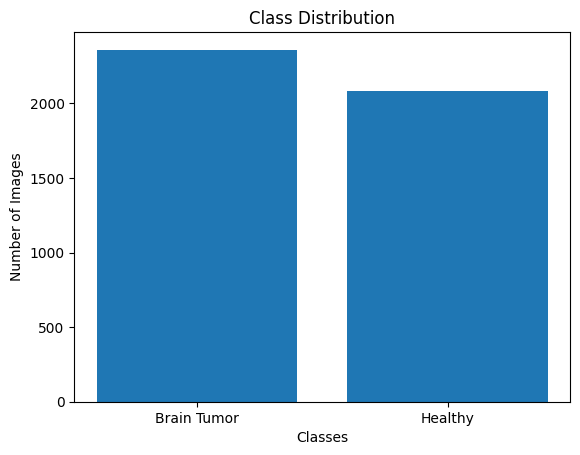

In [12]:
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

Plot Width & Height Distribution

Total images read: 4600


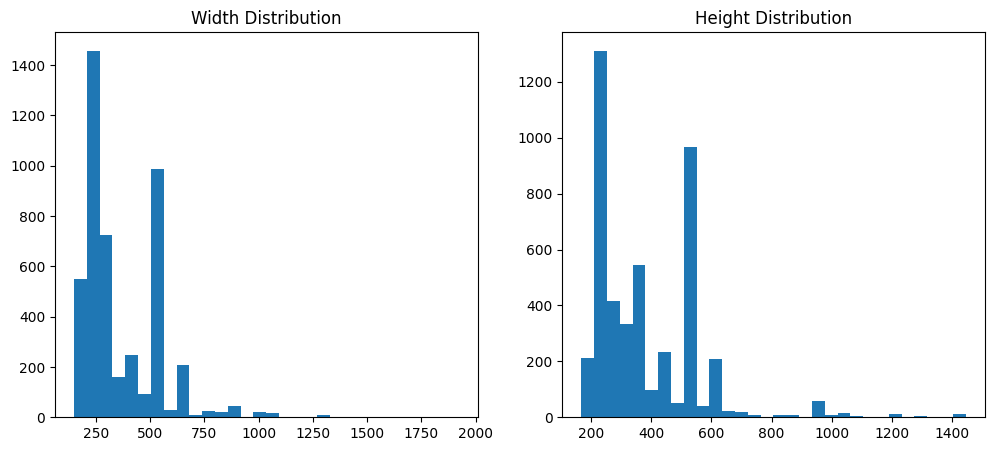

In [13]:
sizes = []

for cls in classes:
    class_path = os.path.join(data_path, cls)
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is not None:
            sizes.append(img.shape)

print("Total images read:", len(sizes))

widths = [size[1] for size in sizes]
heights = [size[0] for size in sizes]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(widths, bins=30)
plt.title("Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=30)
plt.title("Height Distribution")

plt.show()

In [14]:
widths = [size[1] for size in sizes]
heights = [size[0] for size in sizes]

In [15]:
print(len(sizes))

4600


In [16]:
print("Min Width:", min(widths), "Max Width:", max(widths))
print("Min Height:", min(heights), "Max Height:", max(heights))

print("Average Width:", sum(widths)/len(widths))
print("Average Height:", sum(heights)/len(heights))

Min Width: 150 Max Width: 1920
Min Height: 167 Max Height: 1446
Average Width: 359.48847826086956
Average Height: 378.66934782608695


This code creates and displays a bar chart showing number of images in each class.

6. Image Size Analysis

In [17]:
sizes = []

for cls in classes:
    class_path = os.path.join(data_path, cls)
    for img_name in os.listdir(class_path)[:100]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            sizes.append(img.shape)

unique_sizes = set(sizes)
print("Unique Image Sizes:", unique_sizes)

Unique Image Sizes: {(279, 258, 3), (355, 310, 3), (290, 236, 3), (349, 300, 3), (233, 215, 3), (444, 468, 3), (243, 236, 3), (530, 380, 3), (250, 201, 3), (442, 442, 3), (323, 276, 3), (355, 272, 3), (212, 209, 3), (417, 428, 3), (630, 630, 3), (442, 353, 3), (253, 200, 3), (236, 236, 3), (234, 216, 3), (244, 206, 3), (340, 288, 3), (474, 356, 3), (1024, 1024, 3), (217, 232, 3), (600, 494, 3), (352, 321, 3), (238, 212, 3), (308, 244, 3), (353, 300, 3), (223, 226, 3), (380, 294, 3), (442, 332, 3), (1080, 1920, 3), (324, 272, 3), (512, 416, 3), (442, 400, 3), (415, 339, 3), (243, 207, 3), (336, 300, 3), (295, 283, 3), (350, 350, 3), (252, 200, 3), (212, 220, 3), (255, 197, 3), (993, 825, 3), (282, 230, 3), (262, 227, 3), (246, 205, 3), (257, 236, 3), (290, 250, 3), (512, 512, 3), (249, 178, 3), (370, 286, 3), (357, 236, 3), (237, 213, 3), (228, 236, 3), (277, 272, 3), (334, 283, 3), (231, 218, 3), (222, 227, 3), (452, 355, 3), (351, 273, 3), (269, 249, 3), (310, 246, 3), (243, 203, 3), 

This code finds all different image sizes present in your dataset.

7. Sample Visualization





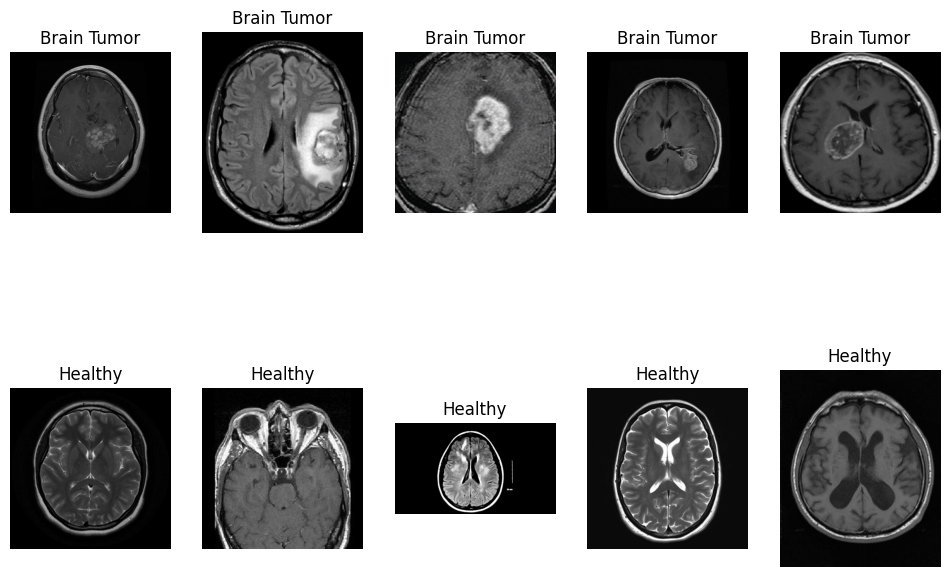

In [18]:
plt.figure(figsize=(12,8))

i = 1
for cls in classes:
    class_path = os.path.join(data_path, cls)

    for img_name in os.listdir(class_path)[:5]:  # 5 images each
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 5, i)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')
        i += 1

plt.show()

This code displays 5 sample images from each class in a grid for visualization.

8. Check Image Blur (Sharpness)

In [19]:
def check_blur(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    return variance

blur_values = []

for cls in classes:
    class_path = os.path.join(data_path, cls)

    for img_name in os.listdir(class_path)[:50]:  # sample check
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            blur_values.append(check_blur(img))

print("Sample Blur Values:", blur_values[:10])
print("Average Sharpness:", sum(blur_values)/len(blur_values))

Sample Blur Values: [np.float64(57.24072265625), np.float64(529.8689444444444), np.float64(320.9175303541124), np.float64(79.31838989257812), np.float64(260.86314310110174), np.float64(51.91528169228695), np.float64(1519.1856233999524), np.float64(160.4499401396327), np.float64(708.7698006541391), np.float64(171.98828400394805)]
Average Sharpness: 889.8904972861212


This code measures how sharp or blurry each image is using edge detection.

9. Check Brightness (Pixel Mean)

In [20]:
means = []

for cls in classes:
    class_path = os.path.join(data_path, cls)

    for img_name in os.listdir(class_path)[:50]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            means.append(np.mean(img))

print("Pixel Mean Range:", min(means), "to", max(means))

Pixel Mean Range: 26.37038845486111 to 131.45899146695714


This code finds how bright or dark your images are by calculating average pixel values.

10. Check Contrast

In [21]:
contrast_values = []

for cls in classes:
    class_path = os.path.join(data_path, cls)

    for img_name in os.listdir(class_path)[:50]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            contrast = gray.std()
            contrast_values.append(contrast)

print("Contrast Values:", contrast_values[:10])
print("Average Contrast:", sum(contrast_values)/len(contrast_values))

Contrast Values: [np.float64(36.55336556474325), np.float64(60.921530334693564), np.float64(39.21333320566657), np.float64(40.666689379693885), np.float64(48.80409673922589), np.float64(47.04293336468792), np.float64(76.1140933717431), np.float64(71.24044895163661), np.float64(69.57858566087637), np.float64(60.098680307733254)]
Average Contrast: 55.34620411513769


This code measures how clear or dull your images are using contrast (pixel variation).

Check Dataset Balance

In [22]:
values = list(class_counts.values())
if max(values) / min(values) > 1.5:
    print("⚠️ Dataset is imbalanced → Risk of bias")
else:
    print("✅ Dataset is balanced")

✅ Dataset is balanced


This code checks if one class has significantly more data than another (dataset balance check).

Check Dataset Size

In [23]:
total_images = sum(values)
print("Total Images:", total_images)

if total_images < 1000:
    print("⚠️ Small dataset → Risk of overfitting")
else:
    print("✅ Dataset size is reasonable")

Total Images: 4440
✅ Dataset size is reasonable


Final Summary

In [24]:
print("\n===== FINAL ANALYSIS =====")

print("Class Distribution:", class_counts)
print("Total Images:", total_images)

print("Avg Sharpness:", sum(blur_values)/len(blur_values))
print("Pixel Diversity Range:", min(means), "to", max(means))
print("Avg Contrast:", sum(contrast_values)/len(contrast_values))


===== FINAL ANALYSIS =====
Class Distribution: {'Brain Tumor': 2359, 'Healthy': 2081}
Total Images: 4440
Avg Sharpness: 889.8904972861212
Pixel Diversity Range: 26.37038845486111 to 131.45899146695714
Avg Contrast: 55.34620411513769


# Day 1 - Dataset Understanding (EDA)
This report includes dataset analysis such as class distribution, image size, visualization, and data quality checks.
## Observations

- The dataset contains 4440 images
- Classes: Brain Tumor (2359), Healthy (2081)
- Slight imbalance present
- Image sizes are different → resizing required
- Data quality is good (high sharpness)
- Pixel variation shows good diversity
- Contrast is good → features visible
- Low risk of underfitting, manageable overfitting risk

“Initially, the dataset folder contained both files and subfolders. After navigating to the correct directory, only class folders were selected using directory filtering. The final classes identified were ‘Brain Tumor’ and ‘Healthy’.”
Summary:
“Overall, the dataset is well-structured and suitable for building a classification model after preprocessing.”

In [25]:
IMG_SIZE = 224

X = []
y = []


All images are converted into a fixed size (224×224), so that the model can process them uniformly.

In [26]:
IMG_SIZE = 224

X = []
y = []

for cls in classes:
    class_path = os.path.join(data_path, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)

            if cls == "Brain Tumor":
                y.append(1)
            else:
                y.append(0)

# Convert
X = np.array(X)
y = np.array(y)

# Normalize
X = X / 255.0

print("Done:", X.shape)

Done: (4600, 224, 224, 3)


Each image is collected into a single dataset (X) which will later be used for training.
We convert categories into numbers:

Tumor → 1
Healthy → 0

In [27]:
X = np.array(X)
y = np.array(y)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

Data shape: (4600, 224, 224, 3)
Labels shape: (4600,)


The image list is converted into a structured numerical format that the model can understand.

In [28]:
X = X / 255.0

Values are scaled to 0–1 range, making training faster and more stable.

In [29]:
X_mean = np.mean(X)
X_std = np.std(X)

X = (X - X_mean) / X_std

print("Data normalized and standardized")


Data normalized and standardized


“Standardization was applied to scale data with zero mean and unit variance, improving training stability.”

In [30]:
outliers = []

for i in range(len(X)):
    if np.mean(X[i]) < -2 or np.mean(X[i]) > 2:
        outliers.append(i)

print("Possible outliers:", len(outliers))

Possible outliers: 0


“Outlier detection was performed based on pixel intensity distribution to identify abnormal images such as overly dark or bright samples.”

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


We need to evaluate the model on unseen data.
80% data → Training
20% data → Testing

In [32]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [33]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.1017964071856288), 1: np.float64(0.9154228855721394)}


Day 2 - Data Cleaning, Balancing & Preprocessing

This report includes preprocessing, data cleaning, handling imbalance, and model selection planning for the brain tumor dataset.

🔹 Observations 
Dataset shows slight class imbalance → handled using class weights
Images had varying sizes → resized to 224x224
Pixel values ranged 0–255 → normalized to 0–1
No major corrupted images → good data quality
Pixel distribution shows good contrast and variation
MRI images include axial & sagittal views → useful for generalization
Augmentation (rotation, zoom, flip) improves robustness
Standardization/normalization ensures stable training

🔹 Conclusion 
Data is clean, consistent, and ready for training
Slight imbalance handled effectively
Suitable for CNN-based image classification

In [44]:
import os
import shutil
import random

In [46]:
source_dir = r"C:\Users\KIMS\OneDrive - Mother Theressa Educational Society\Desktop\brain_tumor_dataset\Brain Tumor Data Set\Brain Tumor Data Set"

base_dir = "dataset"

In [47]:
for split in ["train", "val", "test"]:
    for cls in ["Brain Tumor", "Healthy"]:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

train_ratio = 0.7
val_ratio = 0.15


In [48]:
for cls in ["Brain Tumor", "Healthy"]:
    class_path = os.path.join(source_dir, cls)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = int(total * (train_ratio + val_ratio))

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(base_dir, "train", cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(base_dir, "val", cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(base_dir, "test", cls, img))

print("Dataset split done ✅")

Dataset split done ✅


In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Train (augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

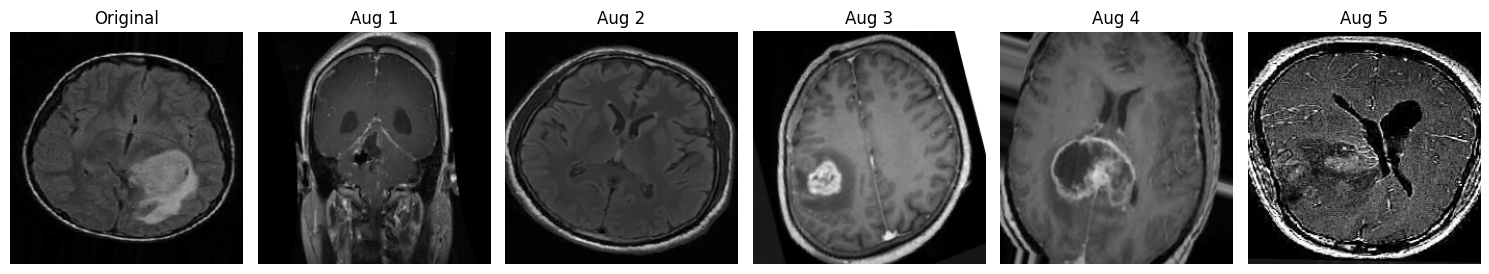

In [53]:
images, labels = next(train_generator)

plt.figure(figsize=(15,5))

# Original image (first one)
plt.subplot(1,6,1)
plt.imshow(images[0])
plt.title("Original")
plt.axis("off")

# Augmented versions
for i in range(5):
    aug_images, _ = next(train_generator)

    plt.subplot(1,6,i+2)
    plt.imshow(aug_images[0])
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [50]:
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    "dataset/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print("Generators ready ✅")

Found 3219 images belonging to 2 classes.
Found 690 images belonging to 2 classes.
Found 691 images belonging to 2 classes.
Generators ready ✅


In [51]:
def get_data_generators():
    return train_generator, val_generator, test_generator

Day 3 - Data Pipeline & Augmentation

This report includes dataset splitting, data generators, and augmentation techniques used to prepare data efficiently for model training.

🔹 Observations

Dataset was successfully split into Train (70%), Validation (15%), and Test (15%)
Class distribution was maintained across all splits
Data generators were used to load images in batches → memory efficient
Training data uses data augmentation:
Rotation
Zoom
Horizontal flip
Validation and test data are only normalized → no augmentation applied
Augmentation creates multiple variations of images → improves model robustness
flow_from_directory avoids loading entire dataset into memory
Generators ensure smooth and efficient data feeding during training

🔹 Conclusion

Data pipeline is well-structured and optimized for training
Augmentation improves generalization and reduces overfitting
Memory-efficient data loading ensures stable execution
Dataset is fully ready for model training using CNN